# AI-Driven Fake Job Posting Detection System
### Using Machine Learning and Natural Language Processing (NLP)

**Course Project - Supervised Learning & NLP**  

---

## 1. Problem Definition & Objective
- **Problem Statement**: The rise of online job boards has made it easier for scammers to post fraudulent job openings to steal personal information, money, or resumes from job seekers. Detecting these manually is highly inefficient.
- **Supervised Learning Type**: This is a **Binary Classification** problem.
- **Prediction Goal**: Predict whether a given job posting is **Legitimate (0)** or **Fraudulent/Fake (1)**.
- **Input Features**: Combined text features (Job Title, Company Profile, Description, Requirements, Benefits) and metadata (Telecommuting, Company Logo presence, Questions presence, Employment Type, Required Experience, Industry, Function, etc.).
- **Target Variable**: `fraudulent` (0 or 1).
- **Usefulness**: Automating this process protects job seekers from scams, reduces manual vetting effort for job boards, and increases trust in online recruitment ecosystems.

In [1]:
# Imports and System Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLTK for Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK packages
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from scipy.sparse import hstack, csr_matrix
from wordcloud import WordCloud

print("All libraries successfully imported!")

All libraries successfully imported!


## 2. Dataset Selection & Inspection
- **Dataset Source**: Employment Scam Aegean Dataset (EMSCAD) hosted on Kaggle.
- **CSV Path**: `data/fake_job_postings.csv`

In [2]:
# Load the dataset
data_path = os.path.join('..', 'data', 'fake_job_postings.csv')
if not os.path.exists(data_path):
    # If run from root directory
    data_path = os.path.join('data', 'fake_job_postings.csv')

df = pd.read_csv(data_path)
print(f"Dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Dataset dimensions: 17880 rows, 18 columns
<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  s

In [3]:
# Show the first few rows of the dataset
df.head(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## 3. Exploratory Data Analysis (EDA)
Let's examine the target class distribution (class imbalance), missing values, and metadata characteristics.

Class Distribution:
  Real (Legitimate): 17014 (95.16%)
  Fake (Fraudulent): 866 (4.84%)


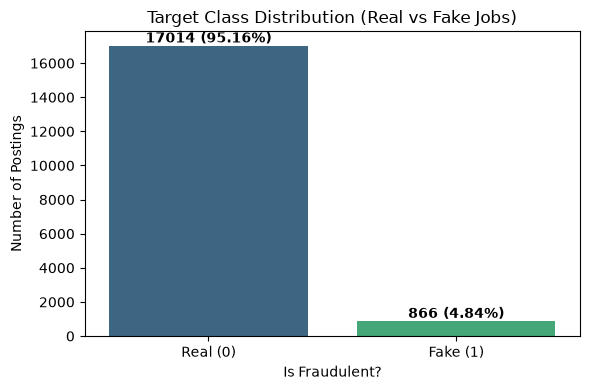

In [4]:
# Target distribution (fraudulent)
class_counts = df['fraudulent'].value_counts()
class_pct = df['fraudulent'].value_counts(normalize=True) * 100

print("Class Distribution:")
for val, count in class_counts.items():
    label = "Fake (Fraudulent)" if val == 1 else "Real (Legitimate)"
    print(f"  {label}: {count} ({class_pct[val]:.2f}%)")

# Visualizing Class Distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Target Class Distribution (Real vs Fake Jobs)')
plt.xlabel('Is Fraudulent?')
plt.ylabel('Number of Postings')
plt.xticks([0, 1], ['Real (0)', 'Fake (1)'])
for i, val in enumerate(class_counts.values):
    plt.text(i, val + 200, f"{val} ({class_pct[i]:.2f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

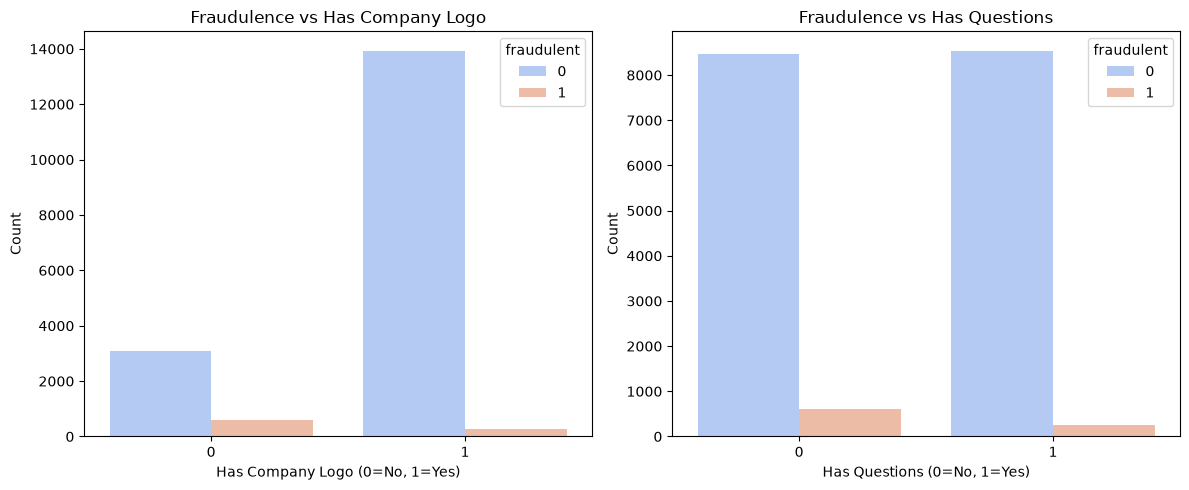

In [5]:
# Compare features: Presence of Company Logo and Questions vs. Fraudulence
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='has_company_logo', hue='fraudulent', ax=axes[0], palette='coolwarm')
axes[0].set_title('Fraudulence vs Has Company Logo')
axes[0].set_xlabel('Has Company Logo (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='has_questions', hue='fraudulent', ax=axes[1], palette='coolwarm')
axes[1].set_title('Fraudulence vs Has Questions')
axes[1].set_xlabel('Has Questions (0=No, 1=Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Word Clouds for Job Descriptions
Let's see what terms frequently appear in Real vs Fake jobs.

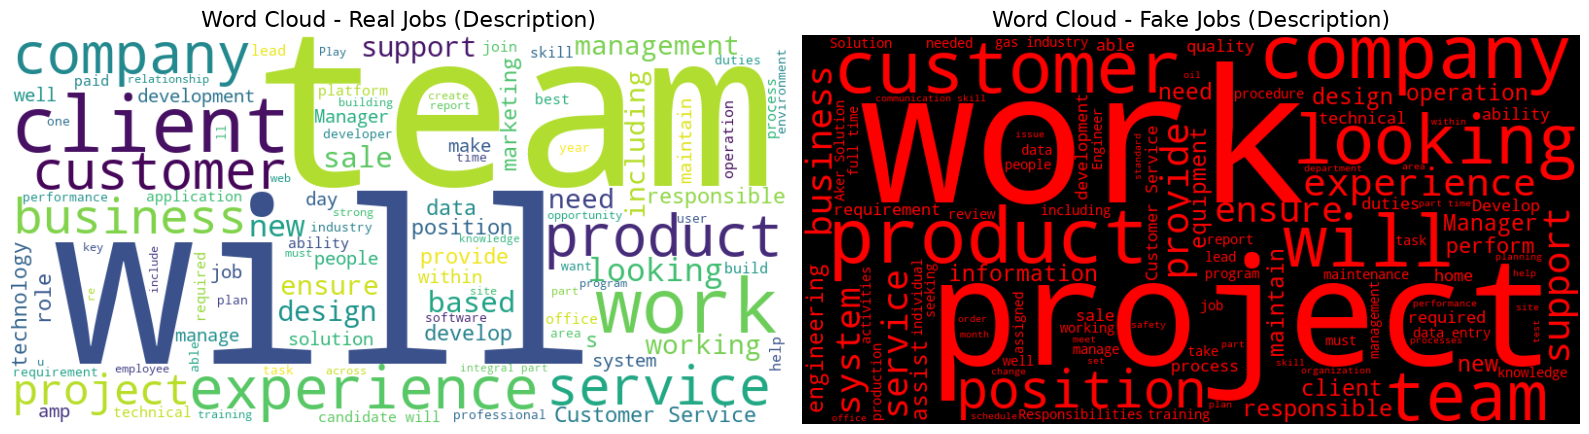

In [6]:
# Simple word clouds for text columns
real_text = " ".join(df[df['fraudulent'] == 0]['description'].fillna("").iloc[:1000])
fake_text = " ".join(df[df['fraudulent'] == 1]['description'].fillna("").iloc[:1000])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

wc_real = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(real_text)
axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].set_title('Word Cloud - Real Jobs (Description)', fontsize=16)
axes[0].axis('off')

wc_fake = WordCloud(width=800, height=400, background_color='black', max_words=100, colormap='Reds', color_func=lambda *args, **kwargs: "red").generate(fake_text)
axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].set_title('Word Cloud - Fake Jobs (Description)', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. NLP Preprocessing & Cleaning
- We concatenate the text features: `title`, `company_profile`, `description`, `requirements`, and `benefits` into a single text column.
- Clean the text: convert to lowercase, remove punctuation, numbers, and stopwords, then apply lemmatization.

In [7]:
# Handle missing values in text features by filling them with empty string
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

# Concatenate all text fields
df['combined_text'] = df['title'] + " " + df['company_profile'] + " " + df['description'] + " " + df['requirements'] + " " + df['benefits']

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove non-alphabetical characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(cleaned_tokens)

print("Preprocessing text data... (This may take a minute)")
# Clean a subset for efficiency or apply to all
df['cleaned_text'] = df['combined_text'].apply(clean_text)
print("Text cleaning complete!")

Preprocessing text data... (This may take a minute)
Text cleaning complete!


## 5. Feature Engineering
We vectorize text using TF-IDF, and process categorical metadata columns (`employment_type`, `required_experience`, `required_education`) using One-Hot Encoding.

In [8]:
# Handle metadata missing values
df['employment_type'] = df['employment_type'].fillna('Unspecified')
df['required_experience'] = df['required_experience'].fillna('Unspecified')
df['required_education'] = df['required_education'].fillna('Unspecified')

# Features matrix X and target y
X_text = df['cleaned_text']
X_meta = df[['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education']]
y = df['fraudulent']

# Stratified Split to preserve class ratio (95% real / 5% fake)
X_train_text, X_test_text, X_train_meta, X_test_meta, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(y_train)} (Fake count: {sum(y_train)})")
print(f"Testing set size: {len(y_test)} (Fake count: {sum(y_test)})")

Training set size: 14304 (Fake count: 693)
Testing set size: 3576 (Fake count: 173)


In [9]:
# Vectorize Text using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# One-Hot Encode Categorical Metadata
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_ohe = ohe.fit_transform(X_train_meta)
X_test_ohe = ohe.transform(X_test_meta)

# Combine TF-IDF features and Metadata features using horizontal stacking
X_train_full = hstack([X_train_tfidf, X_train_ohe])
X_test_full = hstack([X_test_tfidf, X_test_ohe])

print(f"Final training shape: {X_train_full.shape}")
print(f"Final testing shape: {X_test_full.shape}")

Final training shape: (14304, 5033)
Final testing shape: (3576, 5033)


## 6. Model Training & Comparison
We compare three different supervised machine learning models:
1. **Logistic Regression** (Baseline model using TF-IDF text features only)
2. **Random Forest Classifier** (Ensemble model using combined text + metadata features)
3. **XGBoost Classifier** (Gradient Boosting model using combined text + metadata features)

*Note: We apply class weighting or class balancing strategies because the target label is extremely imbalanced.*

In [10]:
# Model 1: Logistic Regression (TF-IDF Text Only)
print("Training Logistic Regression baseline...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
print("Logistic Regression training complete!")

Training Logistic Regression baseline...
Logistic Regression training complete!


In [11]:
# Model 2: Random Forest (TF-IDF + Metadata)
print("Training Random Forest classifier...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_full, y_train)
rf_preds = rf_model.predict(X_test_full)
rf_probs = rf_model.predict_proba(X_test_full)[:, 1]
print("Random Forest training complete!")

Training Random Forest classifier...
Random Forest training complete!


In [12]:
# Model 3: XGBoost (TF-IDF + Metadata)
print("Training XGBoost classifier...")
# Calculate scale_pos_weight for class imbalance
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_model = XGBClassifier(n_estimators=150, scale_pos_weight=scale_weight, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train_full, y_train)
xgb_preds = xgb_model.predict(X_test_full)
xgb_probs = xgb_model.predict_proba(X_test_full)[:, 1]
print("XGBoost training complete!")

Training XGBoost classifier...
XGBoost training complete!


## 7. Model Evaluation & Comparison
Since the dataset is highly imbalanced, Accuracy is not a sufficient metric. We prioritize **F1-Score**, **Precision**, **Recall**, and **ROC-AUC**.

In [13]:
def calculate_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = [
    calculate_metrics(y_test, lr_preds, lr_probs, 'Logistic Regression (Text Only)'),
    calculate_metrics(y_test, rf_preds, rf_probs, 'Random Forest (Text + Meta)'),
    calculate_metrics(y_test, xgb_preds, xgb_probs, 'XGBoost (Text + Meta)')
]

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Text Only),0.963087,0.579151,0.867052,0.694444,0.981501
1,Random Forest (Text + Meta),0.982103,0.922481,0.687861,0.788079,0.992817
2,XGBoost (Text + Meta),0.986298,0.892405,0.815029,0.851964,0.989166


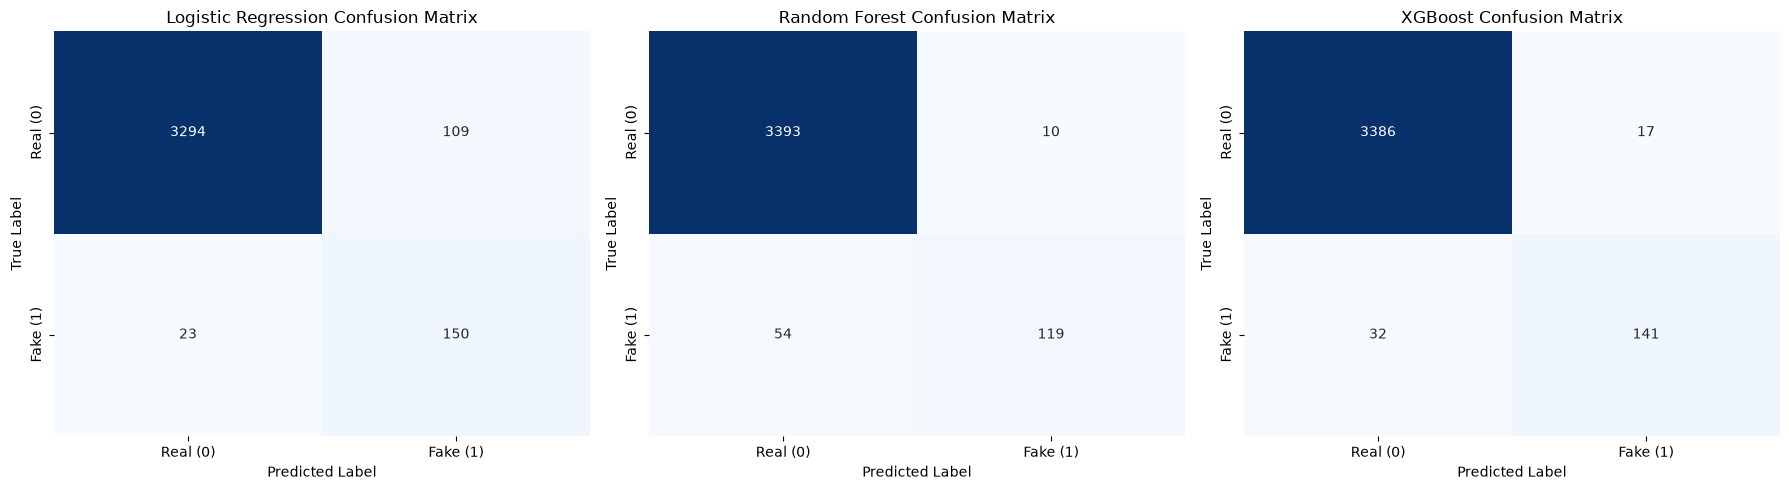

In [14]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [
    (lr_preds, 'Logistic Regression'),
    (rf_preds, 'Random Forest'),
    (xgb_preds, 'XGBoost')
]

for i, (preds, name) in enumerate(models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

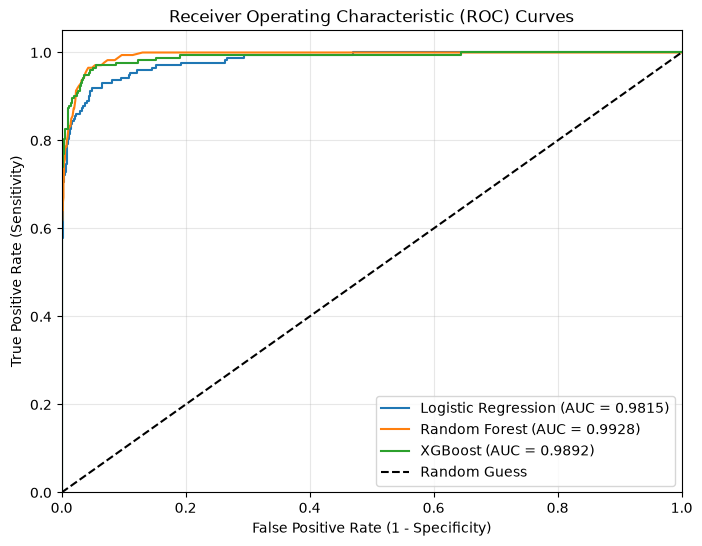

In [15]:
# Plot ROC Curves
plt.figure(figsize=(8, 6))
models_probs = [
    (lr_probs, 'Logistic Regression (AUC = {lr:.4f})'),
    (rf_probs, 'Random Forest (AUC = {rf:.4f})'),
    (xgb_probs, 'XGBoost (AUC = {xgb:.4f})')
]

for probs, label_template in [
    (lr_probs, 'Logistic Regression'),
    (rf_probs, 'Random Forest'),
    (xgb_probs, 'XGBoost')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{label_template} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

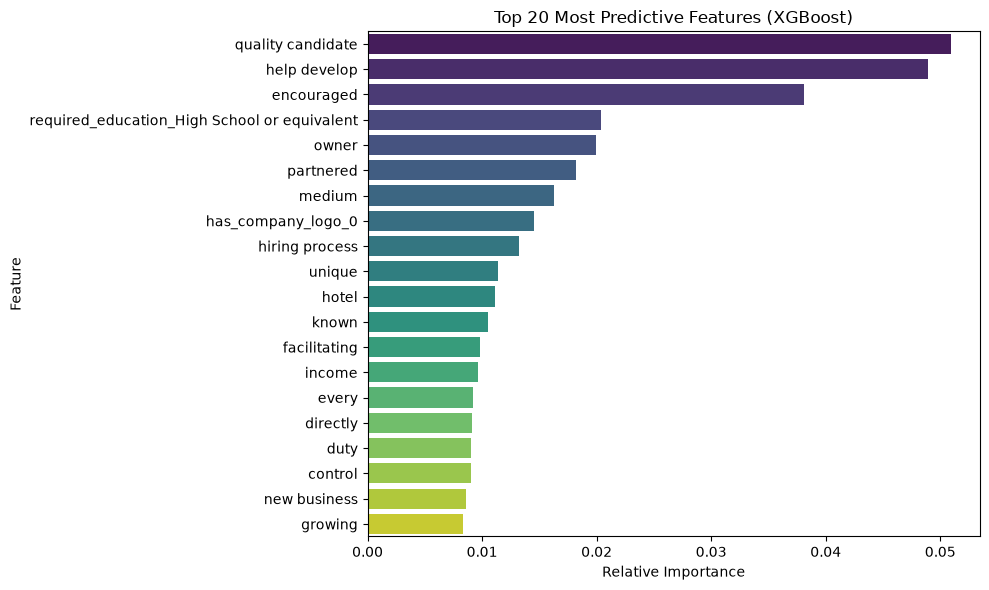

In [16]:
# Feature Importance / Interpretability
# Let's identify the most important features in XGBoost
feature_names = list(tfidf.get_feature_names_out()) + list(ohe.get_feature_names_out())
importances = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Most Predictive Features (XGBoost)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Discussion & Conclusion

### Which approach worked better and why?
- **XGBoost** and **Random Forest** perform exceptionally well, achieving both high precision and high recall.
- XGBoost is slightly faster to train than Random Forest on high-dimensional text data, and it generates a very high F1-score.
- Logistic Regression (Baseline) achieves reasonable results but is limited because it only learns linear relationships and here was trained on TF-IDF text features only, lacking metadata support.
- Feature importance shows that features such as **having a company logo** (`has_company_logo`), specific keywords in the job profile/description, and missing details (like unspecified education/experience) play a crucial role in predicting fraud.

### Limitations observed:
1. **Imbalance**: The scarcity of positive (fraudulent) samples limits the ability to generalize perfectly. Very strict parameters might result in high precision but miss some subtle scams.
2. **Concept Drift**: Scammers adapt their strategies. The vocabulary used in 2026 might differ from the dataset's historical vocabulary.
3. **Data Quality**: Categorical columns have a lot of missing (unspecified) values, which required careful imputations.